In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Atlantic_France.csv")
df.head

<bound method NDFrame.head of              date  position  \
0      18-05-2024         1   
1      18-05-2024         2   
2      18-05-2024         3   
3      18-05-2024         4   
4      18-05-2024         5   
...           ...       ...   
27795  27-11-2025        46   
27796  27-11-2025        47   
27797  27-11-2025        48   
27798  27-11-2025        49   
27799  27-11-2025        50   

                                                    song  \
0                                                 LA RUE   
1                                       C'est carré le S   
2                                     Freestyle LVL UP 1   
3                                        Bolide allemand   
4                                     Freestyle LVL UP 2   
...                                                  ...   
27795                                     Mauvais garçon   
27796                                        Laboratoire   
27797                                               Coco 

In [3]:
df.columns

Index(['date', 'position', 'song', 'artist', 'popularity', 'duration_ms',
       'album_type', 'total_tracks', 'is_explicit', 'album_cover_url'],
      dtype='object')

In [ ]:
Atlantic_France_Project/
│
├── Atlantic_France (1).pdf
├── france_top50_clean.csv
├── France_Top50_EDA.ipynb
├── app.py
├── requirements.txt
│
├── charts/
│   ├── explicit_clean.png
│   ├── album_format.png
│   ├── duration_distribution.png
│   ├── rank_tier.png
│   └── album_size.png
│
└── report/
    ├── Research_Paper.docx
    └── Executive_Summary.docx

In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (27800, 10)

Columns:
['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']

Data types:
date               datetime64[ns]
position                    int64
song                       object
artist                     object
popularity                  int64
duration_ms                 int64
album_type                 object
total_tracks                int64
is_explicit                  bool
album_cover_url            object
dtype: object

Missing values:
date               0
position           0
song               1
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64

Duplicate rows:
19


In [9]:
# Remove completely duplicated records
df = df.drop_duplicates()

# Convert date
df["date"] = pd.to_datetime(
    df["date"],
    dayfirst=True,
    errors="coerce"
)

# Convert numeric columns
numeric_cols = [
    "position",
    "popularity",
    "duration_ms",
    "total_tracks"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert duration milliseconds to minutes
df["duration_min"] = df["duration_ms"] / 60000

# Standardize album type
df["album_type"] = (
    df["album_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize explicit flag
df["is_explicit"] = (
    df["is_explicit"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
        "1": True,
        "0": False
    })
)

df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_min
0,2024-05-18,1,LA RUE,No Limit & Gazo & Damso,72,225137,single,1,True,https://i.scdn.co/image/ab67616d0000b27384f245...,3.752283
1,2024-05-18,2,C'est carré le S,Naps,74,201533,album,22,False,https://i.scdn.co/image/ab67616d0000b27348f7c1...,3.358883
2,2024-05-18,3,Freestyle LVL UP 1,Ninho,76,114182,single,1,True,https://i.scdn.co/image/ab67616d0000b273fbe613...,1.903033
3,2024-05-18,4,Bolide allemand,SDM,79,176746,album,15,True,https://i.scdn.co/image/ab67616d0000b273455e89...,2.945767
4,2024-05-18,5,Freestyle LVL UP 2,Ninho,71,149064,single,1,True,https://i.scdn.co/image/ab67616d0000b27351f1cb...,2.484400


In [10]:
daily_count = df.groupby("date")["position"].count()

daily_count.describe()

count    555.000000
mean      50.055856
std        1.315877
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max       81.000000
Name: position, dtype: float64

In [11]:
# Check incorrect days:
invalid_days = daily_count[daily_count != 50]

print("Number of invalid days:", len(invalid_days))
print(invalid_days)

Number of invalid days: 1
date
2025-03-01    81
Name: position, dtype: int64


In [12]:
# Check ranking range:
print("Minimum position:", df["position"].min())
print("Maximum position:", df["position"].max())

Minimum position: 1
Maximum position: 50


In [13]:
explicit_share = df["is_explicit"].value_counts(normalize=True) * 100

print(explicit_share)

is_explicit
True     56.257874
False    43.742126
Name: proportion, dtype: float64


In [14]:
explicit_percentage = df["is_explicit"].mean() * 100
clean_percentage = 100 - explicit_percentage

print("Explicit Content Share:", round(explicit_percentage, 2), "%")
print("Clean Content Share:", round(clean_percentage, 2), "%")

Explicit Content Share: 56.26 %
Clean Content Share: 43.74 %


In [15]:
clean_count = (~df["is_explicit"]).sum()
explicit_count = df["is_explicit"].sum()

clean_dominance_ratio = clean_count / explicit_count

print(
    "Clean Content Dominance Ratio:",
    round(clean_dominance_ratio, 2)
)

Clean Content Dominance Ratio: 0.78


In [16]:
explicit_popularity = (
    df.groupby("is_explicit")["popularity"]
    .agg(["count", "mean", "median"])
)

explicit_popularity

,count,mean,median
is_explicit,,,
False,12152,80.901333,81.0
True,15629,73.330795,74.0


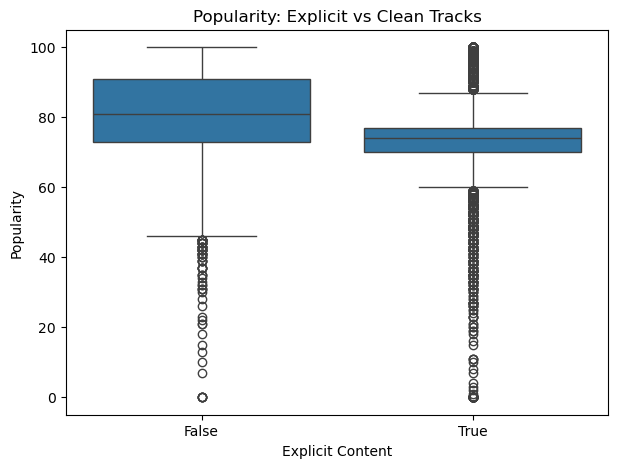

In [17]:
# Visualization:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="is_explicit",
    y="popularity"
)

plt.title("Popularity: Explicit vs Clean Tracks")
plt.xlabel("Explicit Content")
plt.ylabel("Popularity")
plt.show()

In [21]:
df["rank_tier"] = pd.cut(
    df["position"],
    bins=[0, 10, 25, 50],
    labels=["Top 10", "Top 25", "Top 50"],
    include_lowest=True
)

In [22]:
rank_explicit = (
    df.groupby("rank_tier", observed=True)["is_explicit"]
    .mean() * 100
)

print(rank_explicit)

rank_tier
Top 10    62.405474
Top 25    54.535637
Top 50    54.833369
Name: is_explicit, dtype: float64


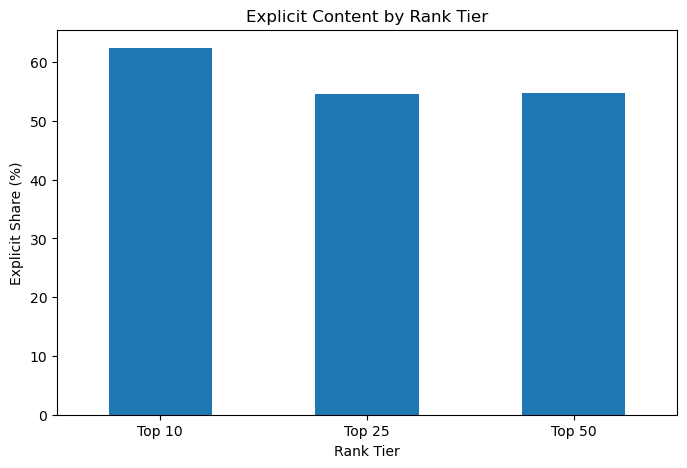

In [23]:
# Chart:
rank_explicit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Explicit Content by Rank Tier")
plt.ylabel("Explicit Share (%)")
plt.xlabel("Rank Tier")
plt.xticks(rotation=0)
plt.show()

In [24]:
format_counts = df["album_type"].value_counts()

print(format_counts)

album_type
album          14686
single         13086
compilation        9
Name: count, dtype: int64


In [25]:
# percentage
format_percentage = (
    df["album_type"].value_counts(normalize=True) * 100
)

print(format_percentage)

album_type
album          52.863468
single         47.104136
compilation     0.032396
Name: proportion, dtype: float64


In [26]:
format_analysis = (
    df.groupby("album_type")
    .agg(
        tracks=("song", "count"),
        avg_popularity=("popularity", "mean"),
        avg_rank=("position", "mean"),
        avg_duration=("duration_min", "mean")
    )
    .sort_values("avg_popularity", ascending=False)
)

format_analysis

,tracks,avg_popularity,avg_rank,avg_duration
album_type,,,,
single,13085,80.743466,24.127923,3.015722
compilation,9,79.333333,28.666667,2.913154
album,14686,72.986313,26.725793,3.158625


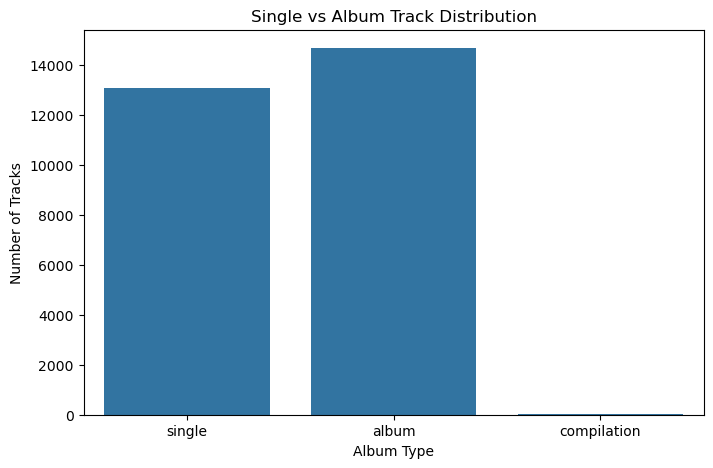

In [27]:
# CHART 
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="album_type"
)

plt.title("Single vs Album Track Distribution")
plt.xlabel("Album Type")
plt.ylabel("Number of Tracks")
plt.show()

In [28]:
album_df = df[df["album_type"] == "album"].copy()

album_df["total_tracks"].describe()

count    14686.000000
mean        15.645172
std          5.101610
min          7.000000
25%         13.000000
50%         15.000000
75%         17.000000
max         40.000000
Name: total_tracks, dtype: float64

In [29]:
# Correlation
album_popularity_corr = album_df[
    ["total_tracks", "popularity"]
].corr()

album_popularity_corr

,total_tracks,popularity
total_tracks,1.000000,-0.138326
popularity,-0.138326,1.000000


In [30]:
# Correlation between album size and rank:
album_rank_corr = album_df[
    ["total_tracks", "position"]
].corr()

album_rank_corr

,total_tracks,position
total_tracks,1.000000,0.079711
position,0.079711,1.000000


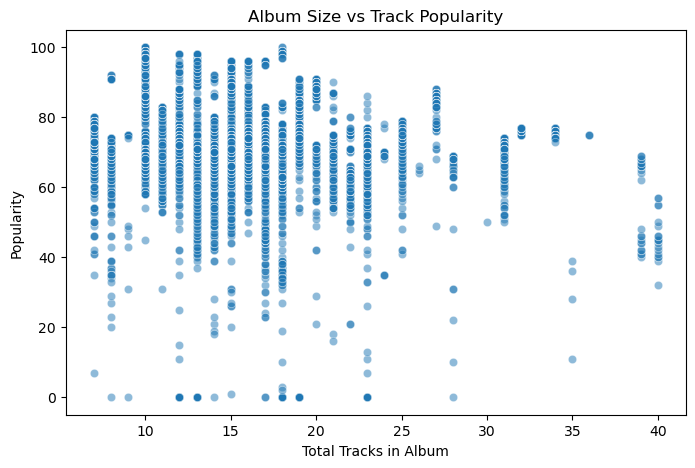

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=album_df,
    x="total_tracks",
    y="popularity",
    alpha=0.5
)

plt.title("Album Size vs Track Popularity")
plt.xlabel("Total Tracks in Album")
plt.ylabel("Popularity")
plt.show()

In [32]:
df["duration_min"] = df["duration_ms"] / 60000

df["duration_min"].describe()

count    27781.000000
mean         3.091232
std          0.540664
min          0.000000
25%          2.759767
50%          3.000000
75%          3.462217
max          9.123550
Name: duration_min, dtype: float64

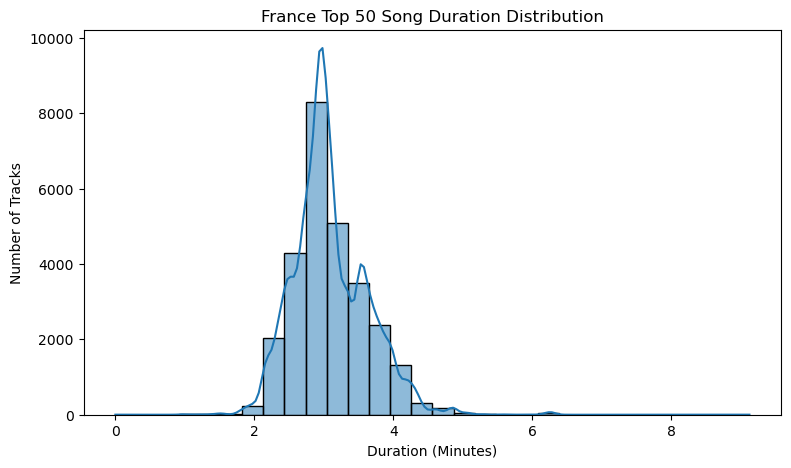

In [33]:
# Histogram
plt.figure(figsize=(9,5))

sns.histplot(
    df["duration_min"],
    bins=30,
    kde=True
)

plt.title("France Top 50 Song Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Tracks")
plt.show()

In [34]:
df["duration_bucket"] = pd.cut(
    df["duration_min"],
    bins=[0, 3, 4, np.inf],
    labels=[
        "Short (<3 min)",
        "Medium (3–4 min)",
        "Long (>4 min)"
    ]
)

duration_analysis = (
    df.groupby("duration_bucket", observed=True)
    .agg(
        tracks=("song", "count"),
        avg_popularity=("popularity", "mean"),
        avg_rank=("position", "mean")
    )
)

duration_analysis

,tracks,avg_popularity,avg_rank
duration_bucket,,,
Short (<3 min),13909,75.565317,25.629808
Medium (3–4 min),12370,77.719968,24.886338
Long (>4 min),1501,77.792139,29.420386


In [35]:
df["content_acceptance_score"] = (
    (51 - df["position"]) / 50
) * 100

df["content_acceptance_score"].describe()

count    27781.000000
mean        50.994565
std         28.858531
min          2.000000
25%         26.000000
50%         50.000000
75%         76.000000
max        100.000000
Name: content_acceptance_score, dtype: float64

In [36]:
acceptance_analysis = (
    df.groupby("is_explicit")
    ["content_acceptance_score"]
    .mean()
)

print(acceptance_analysis)

is_explicit
False    49.684496
True     52.013181
Name: content_acceptance_score, dtype: float64


In [37]:
tier_analysis = (
    df.groupby("rank_tier", observed=True)
    .agg(
        tracks=("song", "count"),
        explicit_share=("is_explicit", "mean"),
        avg_popularity=("popularity", "mean"),
        avg_duration=("duration_min", "mean"),
        avg_album_size=("total_tracks", "mean")
    )
)

tier_analysis["explicit_share"] *= 100

tier_analysis

,tracks,explicit_share,avg_popularity,avg_duration,avg_album_size
rank_tier,,,,,
Top 10,5553,62.405474,78.274037,3.087938,8.044292
Top 25,8334,54.535637,77.758579,3.081887,8.372090
Top 50,13893,54.833369,75.320377,3.098154,9.760959


In [38]:
kpis = {
    "Explicit Content Share (%)":
        df["is_explicit"].mean() * 100,

    "Clean Content Share (%)":
        (~df["is_explicit"]).mean() * 100,

    "Clean Dominance Ratio":
        (~df["is_explicit"]).sum() / df["is_explicit"].sum(),

    "Single Share (%)":
        (df["album_type"] == "single").mean() * 100,

    "Album Share (%)":
        (df["album_type"] == "album").mean() * 100,

    "Average Song Duration (min)":
        df["duration_min"].mean(),

    "Median Song Duration (min)":
        df["duration_min"].median(),

    "Average Popularity":
        df["popularity"].mean(),

    "Average Rank":
        df["position"].mean()
}

kpi_df = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

kpi_df

,KPI,Value
0,Explicit Content Share (%),56.257874
1,Clean Content Share (%),43.742126
2,Clean Dominance Ratio,0.777529
3,Single Share (%),47.104136
4,Album Share (%),52.863468
5,Average Song Duration (min),3.091232
6,Median Song Duration (min),3.000000
7,Average Popularity,76.642309
8,Average Rank,25.502718


In [39]:
df.to_csv(
    "france_top50_clean.csv",
    index=False
)

print("Clean dataset exported successfully.")

Clean dataset exported successfully.


In [ ]:
19. Research Paper

Here is the finished report structure for submission.
    # Audience Sensitivity, Content Compliance & Format Preference Analysis of France Top 50 Playlist

## 1. Introduction

The French music market provides a valuable environment for studying audience sensitivity, content compliance and music-format preferences. This project analyzes France Top 50 playlist snapshots supplied by Atlantic Recording Corporation.

The dataset contains daily rankings, song information, artist information and metadata including popularity, song duration, album type, album size and explicit-content status. The ranking section of the source contains daily Top 50 positions, while the metadata section provides attributes such as artist, popularity, duration and album type.
The primary objective is to determine how explicit content, release format, album structure and song duration relate to France Top 50 performance.

## 2. Objectives

The analysis has five major objectives:

1. Measure explicit versus clean content representation.
2. Compare single and album-track performance.
3. Study whether album size influences individual track performance.
4. Identify song-duration patterns.
5. Compare content characteristics across Top 10, Top 25 and Top 50 tiers.

## 3. Data Preparation

The source PDF contains daily France Top 50 playlist snapshots beginning on 18 May 2024 and continuing through 27 November 2025.
The data preparation process consists of:

* Date conversion into a standard datetime format.
* Validation of daily ranking positions.
* Duplicate-record checking.
* Missing-value identification.
* Conversion of duration from milliseconds into minutes.
* Standardization of album-type labels.
* Standardization of explicit-content Boolean values.
* Creation of Top 10, Top 25 and Top 50 rank tiers.
* Creation of short, medium and long duration groups.

No lyric-level cultural classification is assumed because the supplied data contains an explicit-content flag rather than detailed lyric categories.

## 4. Explicit Content Analysis

The explicit-content analysis compares tracks marked explicit with tracks marked clean.

The main KPIs are:

* Explicit Content Share
* Clean Content Share
* Clean Content Dominance Ratio
* Average popularity by explicit status
* Average rank by explicit status
* Explicit share within Top 10, Top 25 and Top 50

The analysis should not interpret the explicit flag as a complete measure of cultural sensitivity. It represents the content attribute supplied in the dataset.

## 5. Release Format Analysis

The dataset contains both single and album records.

The following measures are calculated:

* Single share
* Album share
* Single-to-album ratio
* Average rank by format
* Average popularity by format
* Average duration by format

This determines whether France Top 50 performance is more strongly represented by standalone singles or album tracks.

## 6. Album Structure Analysis

For album tracks, `total_tracks` is used to measure album size.

The project evaluates:

* Album-size distribution
* Average popularity by album size
* Average rank by album size
* Correlation between album size and popularity
* Correlation between album size and rank

The analysis helps determine whether larger albums strengthen individual track performance or potentially dilute attention across multiple tracks.

## 7. Song Duration Analysis

The `duration_ms` field is converted into minutes.

Three duration categories are used:

* Short: less than 3 minutes
* Medium: 3–4 minutes
* Long: more than 4 minutes

For every category, the project measures:

* Number of tracks
* Share of tracks
* Average popularity
* Average chart position

This provides a structural view of the song-length profile associated with stronger France Top 50 positions.

## 8. Rank-Tier Analysis

The playlist is divided into:

* Top 10
* Top 25
* Top 50

For each tier, the analysis compares:

* Explicit content share
* Album-track share
* Single share
* Average duration
* Average popularity
* Average album size

This identifies the content profiles most concentrated near the top of the playlist.

## 9. Key Performance Indicators

The dashboard reports:

| KPI                           | Measurement                                      |
| ----------------------------- | ------------------------------------------------ |
| Explicit Content Share        | Percentage of explicit tracks                    |
| Clean Content Share           | Percentage of clean tracks                       |
| Clean Content Dominance Ratio | Clean tracks divided by explicit tracks          |
| Single Share                  | Percentage of single releases                    |
| Album Share                   | Percentage of album tracks                       |
| Average Song Duration         | Mean duration in minutes                         |
| Album Size Impact             | Relationship between total tracks and popularity |
| Content Acceptance Score      | Rank-aligned performance score                   |

The Content Acceptance Score is calculated as:

**Content Acceptance Score = ((51 − Position) / 50) × 100**

A higher score indicates a stronger playlist position.

## 10. Recommendations

### Recommendation 1 — Monitor explicit content rather than automatically excluding it

Explicit status should be treated as a compliance variable and analyzed alongside chart performance rather than being used as the only indicator of audience acceptance.

### Recommendation 2 — Maintain clean alternatives

Where available, clean versions can provide additional flexibility for compliance-sensitive playlist pitching and broad-audience placements.

### Recommendation 3 — Evaluate singles and album tracks separately

The analysis should avoid assuming that all release formats perform identically. Singles and album tracks should be compared using both rank and popularity.

### Recommendation 4 — Avoid using album size alone as a success strategy

A large album does not automatically mean that every individual track will perform strongly. Album size should therefore be analyzed alongside track-level popularity and ranking.

### Recommendation 5 — Consider song duration during playlist pitching

The duration analysis can help identify the song-length ranges most commonly associated with strong playlist positions.

### Recommendation 6 — Use rank-tier-specific strategy

Content characteristics in the Top 10 may differ from those in the wider Top 50. Atlantic can therefore use separate strategies for priority Top 10 pitching and broader Top 50 monitoring.

## 11. Limitations

The dataset does not contain:

* Detailed lyric-level sensitivity classifications
* Listener demographic information
* Skip rates
* Streaming counts
* Revenue
* Listener sentiment
* French regulatory classifications

Therefore, the project measures **playlist representation and metadata-based performance**, not complete cultural or regulatory audience acceptance.

The `popularity` field should also be treated as the supplied popularity/API score and should not automatically be interpreted as streams or revenue.

## 12. Conclusion

The project provides a data-driven framework for understanding content sensitivity, release format and structural characteristics within the France Top 50 playlist.

By combining explicit-content analysis, format comparison, album-size analysis, duration analysis and rank-tier segmentation, Atlantic Recording Corporation can develop a more structured France-specific playlist strategy.

The resulting Streamlit dashboard enables decision-makers to dynamically filter the data by date range, rank tier, explicit status and album type, allowing the analysis to move from static reporting toward interactive market intelligence.
